
  SOLANA (SOL) vs BOVESPA (IBOV) — IMPACT ANALYSIS

  Detected files:
    Bovespa Index : /content/Bovespa Historical Data.csv
    Solana        : /content/Solana Historical Data_crypto.csv

  Data loaded: 68 overlapping trading days (weekends dropped)
  Period : Aug 2020 → Mar 2026

      Date  SOL_Return  IBOV_Return
2020-08-01      2.0594      -0.0344
2020-09-01     -0.3929      -0.0480
2020-10-01     -0.4651      -0.0069
2020-11-01      0.2728       0.1590
2020-12-01     -0.2301       0.0930
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
             Count    Mean     Std     Min     25%     50%     75%     Max
SOL_Return    68.0  0.1636  0.5794 -0.5654 -0.1884  0.0310  0.2616  2.0605
IBOV_Return   68.0  0.0098  0.0533 -0.1150 -0.0307  0.0114  0.0473  0.1590

  Pearson Correlation (Solana vs Bovespa): -0.0982


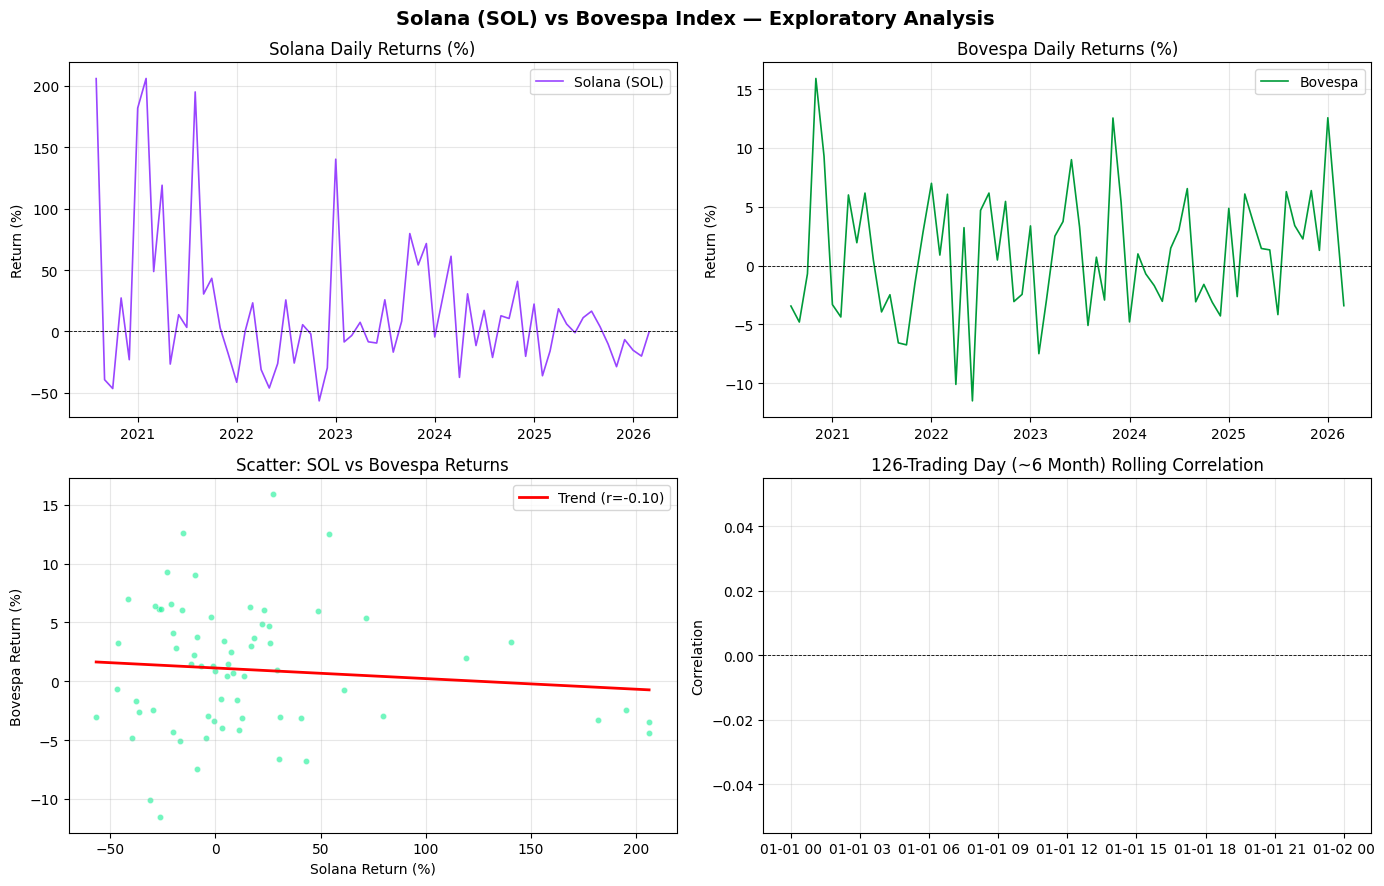


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average Solana Return  (X̄) = 16.3612%
    Average Bovespa Return (Ȳ) = 0.9822%

  Step 4 — Slope β
    β = -0.0090
    → For every 1% rise in SOL, Bovespa changes by ~-0.0090%

  Step 5 — Intercept α = 0.011298

  Step 6 — Regression Equation
    IBOV_Return = 0.011298 + -0.0090 × SOL_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 0.0113
    t-statistic = -0.8014
    p-value     = 0.4258
    ✘ NOT significant — Fail to reject H₀

  Step 8 — Goodness of Fit
    R² = 0.0096  (0.96% of Bovespa variation explained by SOL)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:            IBOV_Return   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.6422
D

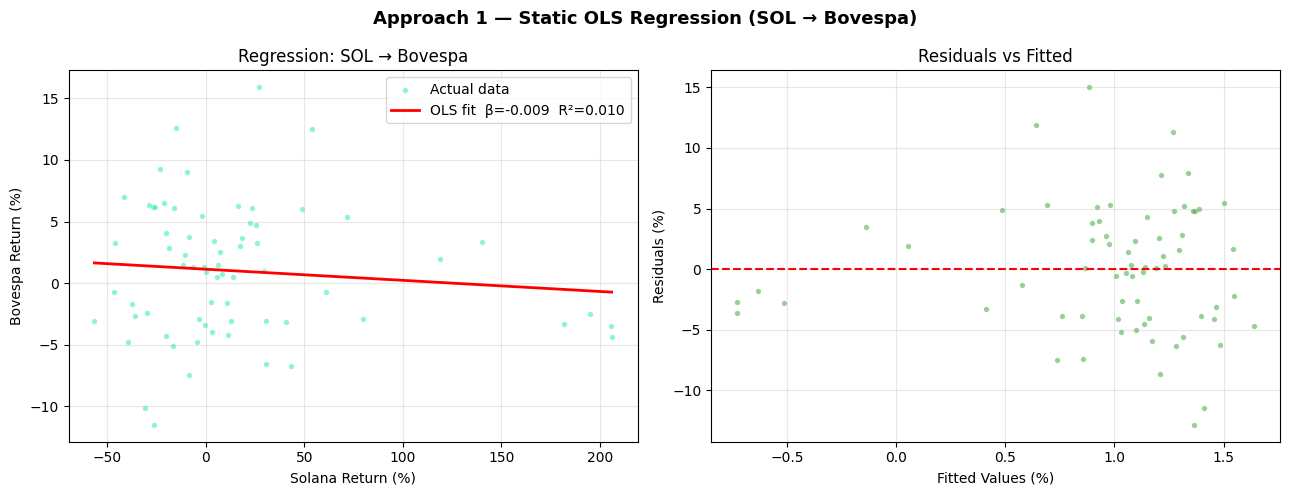


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    SOL Return                | ADF stat =  -2.255 | p = 0.1868 | ⚠ Non-Stationary
    Bovespa Return            | ADF stat =  -5.860 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of Bovespa Returns
    Lag-1 autocorrelation: 0.0675
    Lag-2 autocorrelation: -0.0509
    Low autocorrelation — lagged term adds robustness

  Step 4 & 5 — Building Dynamic Regression Model
    Model: IBOV_t = α + β×SOL_t + γ×IBOV_(t-1)

    Estimated equation:
    IBOV_t = 0.01061 + -0.0059×SOL_t + 0.0638×IBOV_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=-0.0059  t=-0.470  p=0.6400  ✘ Not significant
    Lag effect   (γ): coef=0.0638  t=0.511  p=0.6108  ✘ Not significant

    R² (dynamic model) = 0.0080
    Adj. R²            = -0.0230

  Step 7 — Granger Causality Test
    H₀: SOL returns do NOT Granger-cause Bovespa returns
    Sample size: 68 

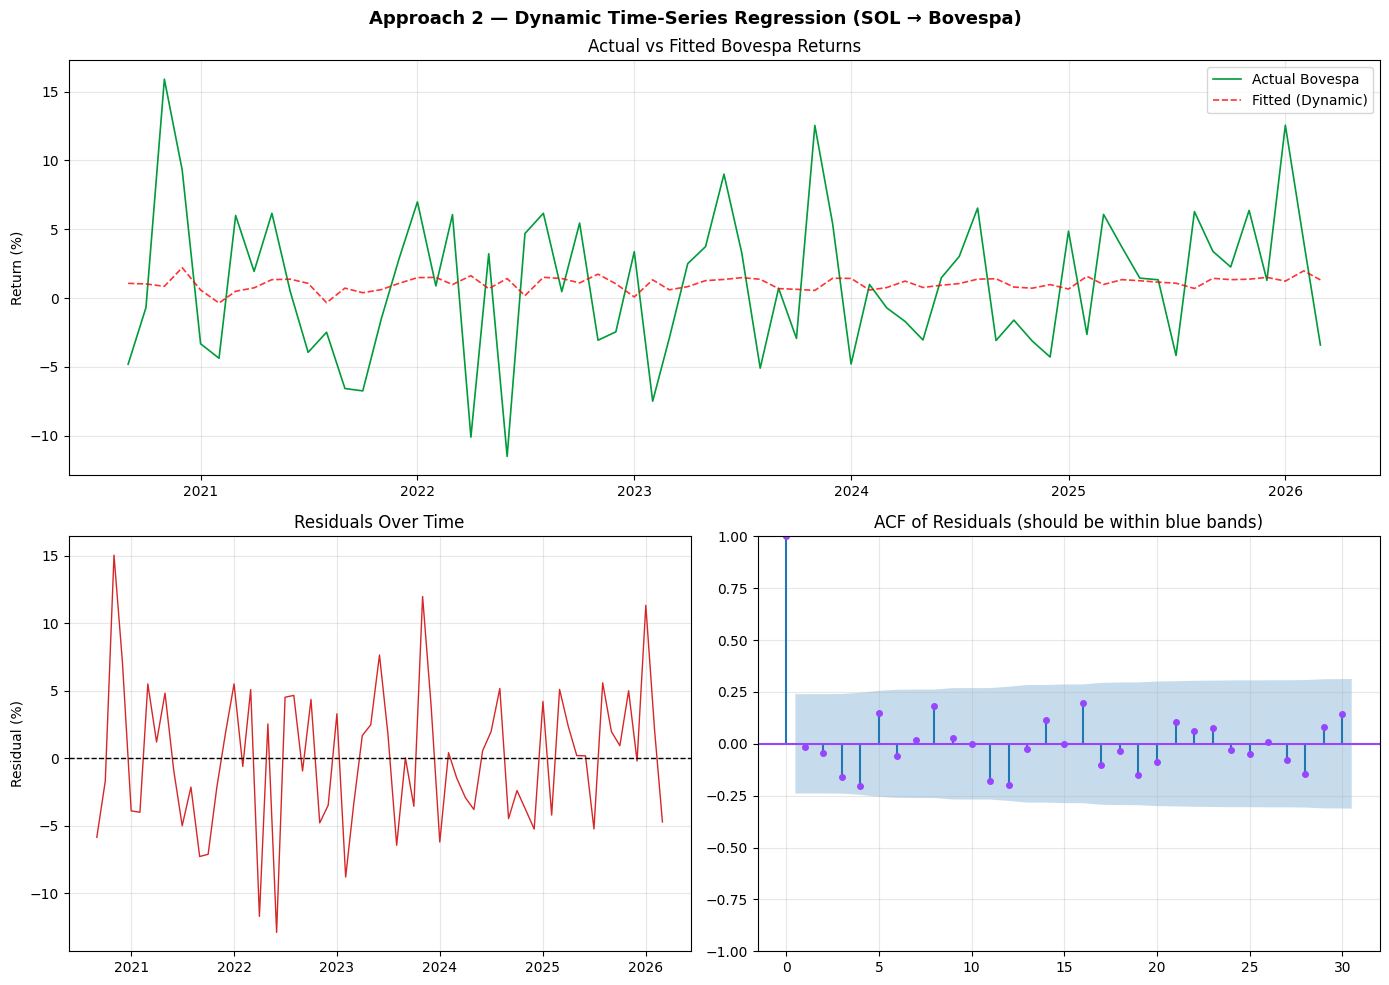


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                 -0.0090                   -0.0059
Lag Term (γ)                Not included                    0.0638
p-value (crypto)                  0.4258                    0.6400
R²                                0.0096                    0.0080
Accounts for Memory?                  No                       Yes


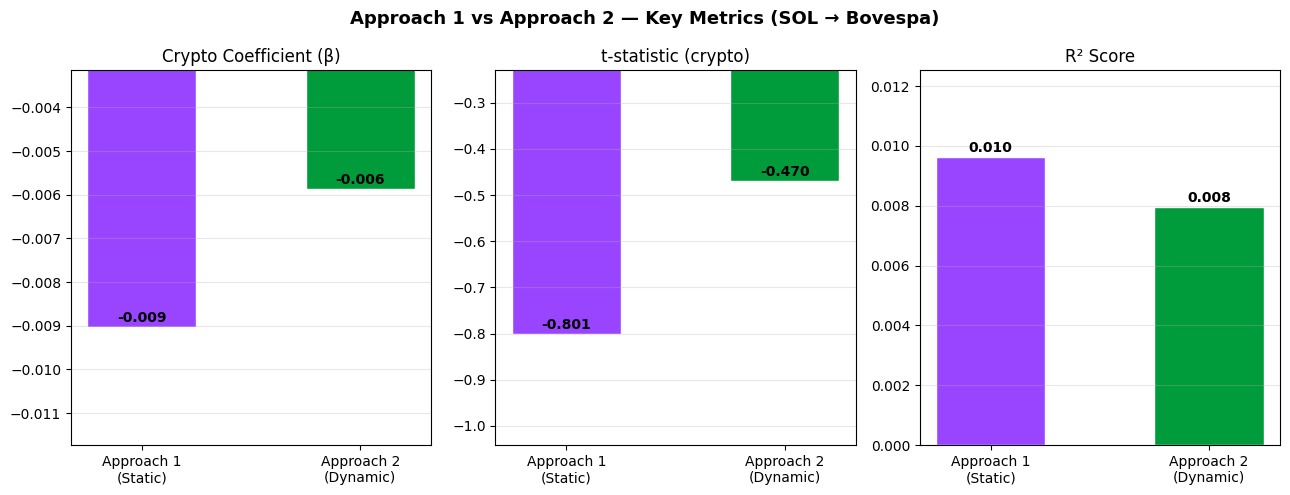


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Solana (SOL) impact on Bovespa Index (Brazil):

  ▸ Approach 1 (Static OLS):
      β = -0.0090 — a 1% SOL change correlates with ~-0.009% Bovespa change
      R² = 0.0096
      Result: NOT SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = -0.0059 — immediate effect after controlling for momentum
      γ = 0.0638 — 6.4% of prior period's Bovespa return persists
      R² = 0.0080
      Result: NOT SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS FOR BRAZIL & SOLANA:
  1. Fundamentally Divergent Assets: Solana is a high-beta, highly volatile Layer-1 
     blockchain driven by decentralized finance (DeFi), NFT volumes, and network 
     upgrades. The Bovespa (Ibovespa) is a traditional emerging market index heavily 
     weighted toward commodities (Petrobras, Vale) and banking (Itaú, Bradesco). 
  2. The BRL Currency Factor: The Brazilian Real (BRL) floats and can be volatile. 
    

In [ ]:
# ============================================================
#   SOLANA (SOL) vs BOVESPA (IBOVESPA) — IMPACT ANALYSIS
# ============================================================


import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])


import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both Bovespa and Solana CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


BOVESPA_FILE = next((f for f in csv_files if "Bovespa" in os.path.basename(f) or "bovespa" in os.path.basename(f)), None)
SOL_FILE     = next((f for f in csv_files if "Solana" in os.path.basename(f) or "solana" in os.path.basename(f)
                                          or "SOL" in os.path.basename(f)), None)


if BOVESPA_FILE is None or SOL_FILE is None:
    remaining = [f for f in csv_files if f not in (BOVESPA_FILE, SOL_FILE)]
    if BOVESPA_FILE is None and remaining:
        BOVESPA_FILE = remaining.pop(0)
    if SOL_FILE is None and remaining:
        SOL_FILE = remaining.pop(0)

if BOVESPA_FILE is None or SOL_FILE is None:
    raise FileNotFoundError(
        "Could not identify both Bovespa and Solana CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'Bovespa' and 'Solana'."
    )

print("\n" + "=" * 65)
print("  SOLANA (SOL) vs BOVESPA (IBOV) — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    Bovespa Index : {BOVESPA_FILE}")
print(f"    Solana        : {SOL_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()
    # Handle potentially different date formats gracefully
    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)

    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)  # Remove any stray commas
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

sol = load_and_clean(SOL_FILE, "SOL_Return")
ibov = load_and_clean(BOVESPA_FILE, "IBOV_Return")


data = pd.merge(sol, ibov, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "SOL_Return", "IBOV_Return"]].head().to_string(index=False))
print("  ...")

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["SOL_Return", "IBOV_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["SOL_Return"].corr(data["IBOV_Return"])
print(f"\n  Pearson Correlation (Solana vs Bovespa): {corr:.4f}")

# Plot 1: Exploratory Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Solana (SOL) vs Bovespa Index — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["SOL_Return"] * 100, color="#9945FF", label="Solana (SOL)", linewidth=1.2) # Solana Purple
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Solana Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["IBOV_Return"] * 100, color="#009B3A", label="Bovespa", linewidth=1.2) # Brazil Green
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Bovespa Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["SOL_Return"] * 100, data["IBOV_Return"] * 100,
           alpha=0.6, color="#14F195", edgecolors="white", linewidth=0.4, s=20) # Solana Green
m, b = np.polyfit(data["SOL_Return"], data["IBOV_Return"], 1)
x_line = np.linspace(data["SOL_Return"].min(), data["SOL_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100, color="red", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Solana Return (%)")
ax.set_ylabel("Bovespa Return (%)")
ax.set_title("Scatter: SOL vs Bovespa Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
# 126 Trading Days (~6 Months) Rolling Correlation
roll_corr = data["SOL_Return"].rolling(126).corr(data["IBOV_Return"])
ax.plot(data["Date"], roll_corr, color="#009B3A", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["SOL_Return"]
Y = data["IBOV_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average Solana Return  (X̄) = {x_mean*100:.4f}%")
print(f"    Average Bovespa Return (Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator if denominator != 0 else 0
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in SOL, Bovespa changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    IBOV_Return = {alpha:.6f} + {beta:.4f} × SOL_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse.get("SOL_Return", np.nan)
t_stat    = ols_model.tvalues.get("SOL_Return", np.nan)
p_value   = ols_model.pvalues.get("SOL_Return", np.nan)

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")

if pd.notna(t_stat) and abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of Bovespa variation explained by SOL)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (SOL → Bovespa)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#14F195", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Solana Return (%)")
ax.set_ylabel("Bovespa Return (%)")
ax.set_title("Regression: SOL → Bovespa")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#2ca02c", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["SOL_Return"], "SOL Return"),
                     (data["IBOV_Return"], "Bovespa Return")]:
    if series.std() > 1e-6:
        adf_result = adfuller(series.dropna())
        stat, pval = adf_result[0], adf_result[1]
        flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
        print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")
    else:
        print(f"    {name:25s} | Variance too low for reliable ADF test")

print("\n  Step 3 — Autocorrelation of Bovespa Returns")
lag1_autocorr = data["IBOV_Return"].autocorr(lag=1)
lag2_autocorr = data["IBOV_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: IBOV_t = α + β×SOL_t + γ×IBOV_(t-1)")

data_dyn = data.copy()
data_dyn["IBOV_Lag1"] = data_dyn["IBOV_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["IBOV_Return"]
X_dyn = sm.add_constant(data_dyn[["SOL_Return", "IBOV_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params.get("SOL_Return", 0)
gamma_dyn = dyn_model.params.get("IBOV_Lag1", 0)

print(f"\n    Estimated equation:")
print(f"    IBOV_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×SOL_t + {gamma_dyn:.4f}×IBOV_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["SOL_Return", "IBOV_Lag1"]:
    if var in dyn_model.tvalues:
        t  = dyn_model.tvalues[var]
        p  = dyn_model.pvalues[var]
        label = "Crypto effect (β)" if var == "SOL_Return" else "Lag effect   (γ)"
        sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
        print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: SOL returns do NOT Granger-cause Bovespa returns")
granger_data = data[["IBOV_Return", "SOL_Return"]].dropna()

if granger_data["SOL_Return"].var() > 1e-8:
    max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
    granger_maxlag    = min(5, max_allowable_lag)
    print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
    try:
        gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)
        for lag, res in gc_results.items():
            f_stat = res[0]["ssr_ftest"][0]
            p_gc   = res[0]["ssr_ftest"][1]
            flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
            print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")
    except Exception as e:
        print(f"    Granger Causality failed: {e}")
else:
    print("    Skipping Granger Causality due to near-zero variance in SOL.")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (SOL → Bovespa)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#009B3A", linewidth=1.2, label="Actual Bovespa")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="red", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted Bovespa Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#d62728", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#9945FF", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

p_val_static  = p_value if pd.notna(p_value) else 1.0
p_val_dynamic = dyn_model.pvalues.get("SOL_Return", 1.0)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_val_static:.4f}", f"{p_val_dynamic:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (SOL → Bovespa)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat if pd.notna(t_stat) else 0, dyn_model.tvalues.get("SOL_Return", 0)),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#9945FF", "#009B3A"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals if pd.notna(v)),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)


    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_val_static < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if p_val_dynamic < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Solana (SOL) impact on Bovespa Index (Brazil):

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% SOL change correlates with ~{beta:.3f}% Bovespa change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's Bovespa return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS FOR BRAZIL & SOLANA:
  1. Fundamentally Divergent Assets: Solana is a high-beta, highly volatile Layer-1
     blockchain driven by decentralized finance (DeFi), NFT volumes, and network
     upgrades. The Bovespa (Ibovespa) is a traditional emerging market index heavily
     weighted toward commodities (Petrobras, Vale) and banking (Itaú, Bradesco).
  2. The BRL Currency Factor: The Brazilian Real (BRL) floats and can be volatile.
     Unlike the hyperinflation scenarios of Argentina, Brazil's Central Bank (BCB)
     aggressively targets inflation using the Selic rate. Institutional investors in
     the Bovespa are watching local interest rates and global iron ore/oil prices,
     not Layer-1 crypto altcoins.
  3. "Not Significant" is Expected: Given Solana's massive historical volatility
     and specific tech-driven market cycles, attempting to regress the Bovespa
     against SOL is highly likely to yield zero statistical significance, proving
     that altcoin price action has no predictive power over Brazilian blue-chip equities.
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)